# Subject 01 retinotopy with V1 overlay

This notebook plots subject 01's polar-angle and eccentricity phase maps on the subject's inflated cortical surface. Sulcal curvature provides the anatomical brain background, and the subject-specific FreeSurfer V1 label is drawn as a white boundary.

The retinotopy files contain phase in frame 0 and response strength in frame 1. Only vertices meeting the configurable response threshold are colored.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nibabel.freesurfer.io import read_label
from nilearn import plotting

## Paths and display parameters

A medial view is used because V1 lies along the calcarine sulcus. Change `response_threshold` to control how conservatively the retinotopic phase is displayed.

In [2]:
subject = "sub-01"
response_threshold = 0.40

retino_dir = Path(
    "studyforrest-data/derivative/retinotopic_maps/"
    f"{subject}/surface_maps"
)
freesurfer_dir = Path("studyforrest-aux/freesurfer") / subject

polar_output = Path("sub-01_retinotopy_polar_V1-overlay.png")
eccentricity_output = Path("sub-01_retinotopy_eccentricity_V1-overlay.png")

## Load the surface maps and V1 labels

In [3]:
def hemisphere_data(map_name, hemi, threshold=response_threshold):
    """Load one retinotopic map and its matching surface/V1 data."""
    map_path = retino_dir / f"combined_pipeline_{map_name}_{hemi}.mgh"
    surface_path = freesurfer_dir / "surf" / f"{hemi}.inflated"
    sulc_path = freesurfer_dir / "surf" / f"{hemi}.sulc"
    v1_path = freesurfer_dir / "label" / f"{hemi}.V1.label"

    frames = np.squeeze(np.asanyarray(nib.load(map_path).dataobj))
    if frames.ndim != 2 or frames.shape[1] < 2:
        raise ValueError(f"Expected phase and response frames in {map_path}")

    phase = frames[:, 0].astype(np.float32)
    response = frames[:, 1].astype(np.float32)
    masked_phase = np.where(response >= threshold, phase, 0.0)

    v1_mask = np.zeros(phase.shape[0], dtype=np.int8)
    v1_vertices = read_label(v1_path)
    v1_mask[v1_vertices] = 1

    return {
        "phase": masked_phase,
        "response": response,
        "surface": surface_path,
        "sulc": sulc_path,
        "v1_mask": v1_mask,
        "v1_vertices": v1_vertices,
    }


for hemi in ("lh", "rh"):
    data = hemisphere_data("polar", hemi)
    print(
        f"{hemi}: {data['phase'].size:,} surface vertices; "
        f"{data['v1_vertices'].size:,} V1 vertices; "
        f"{(data['response'] >= response_threshold).sum():,} responsive vertices"
    )

lh: 151,296 surface vertices; 5,309 V1 vertices; 16,727 responsive vertices
rh: 151,707 surface vertices; 5,848 V1 vertices; 15,594 responsive vertices


In [4]:
def plot_retinotopy_with_v1(map_name, output_path):
    """Plot left/right medial surfaces with the V1 boundary over phase."""
    display_name = "Polar angle" if map_name == "polar" else "Eccentricity"
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        subplot_kw={"projection": "3d"},
        constrained_layout=True,
    )

    for ax, hemi, hemi_name in zip(
        axes, ("lh", "rh"), ("Left hemisphere", "Right hemisphere")
    ):
        data = hemisphere_data(map_name, hemi)
        plotting.plot_surf_stat_map(
            surf_mesh=data["surface"],
            stat_map=data["phase"],
            bg_map=data["sulc"],
            hemi="left" if hemi == "lh" else "right",
            view="medial",
            cmap="hsv",
            vmin=0,
            vmax=360,
            threshold=0.1,
            symmetric_cbar=False,
            colorbar=True,
            axes=ax,
            figure=fig,
            engine="matplotlib",
            title=hemi_name,
        )
        plotting.plot_surf_contours(
            surf_mesh=data["surface"],
            roi_map=data["v1_mask"],
            levels=[1],
            colors=["white"],
            labels=["V1 boundary"],
            legend=True,
            axes=ax,
            figure=fig,
            engine="matplotlib",
        )

    fig.suptitle(
        f"Subject 01 | {display_name} phase on inflated cortex | "
        f"response ≥ {response_threshold:.2f}",
        fontsize=18,
    )
    fig.savefig(output_path, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_path.resolve()}")

## Polar-angle phase with V1 boundary

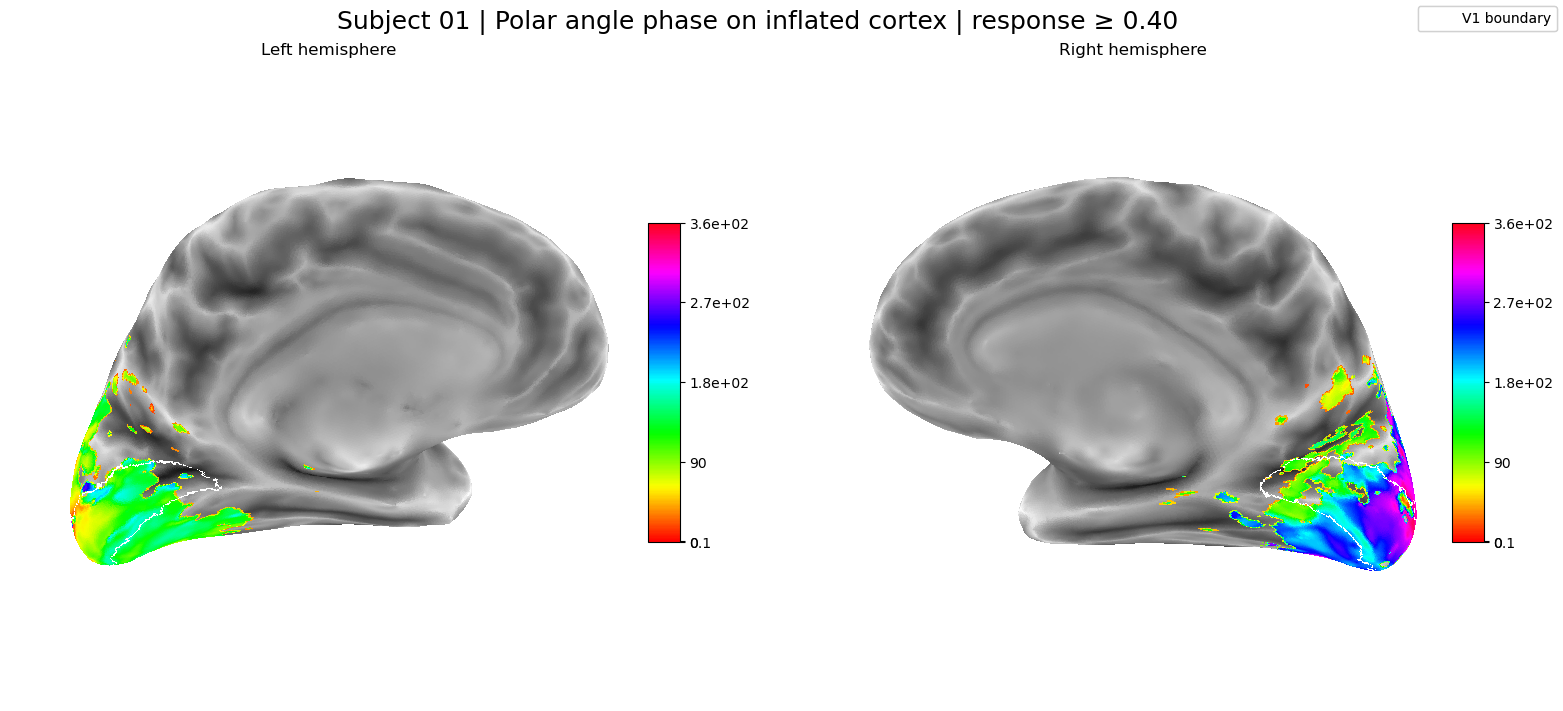

Saved: /home/jovyan/junruz/forrestgump/sub-01_retinotopy_polar_V1-overlay.png


In [5]:
plot_retinotopy_with_v1("polar", polar_output)

## Eccentricity phase with V1 boundary

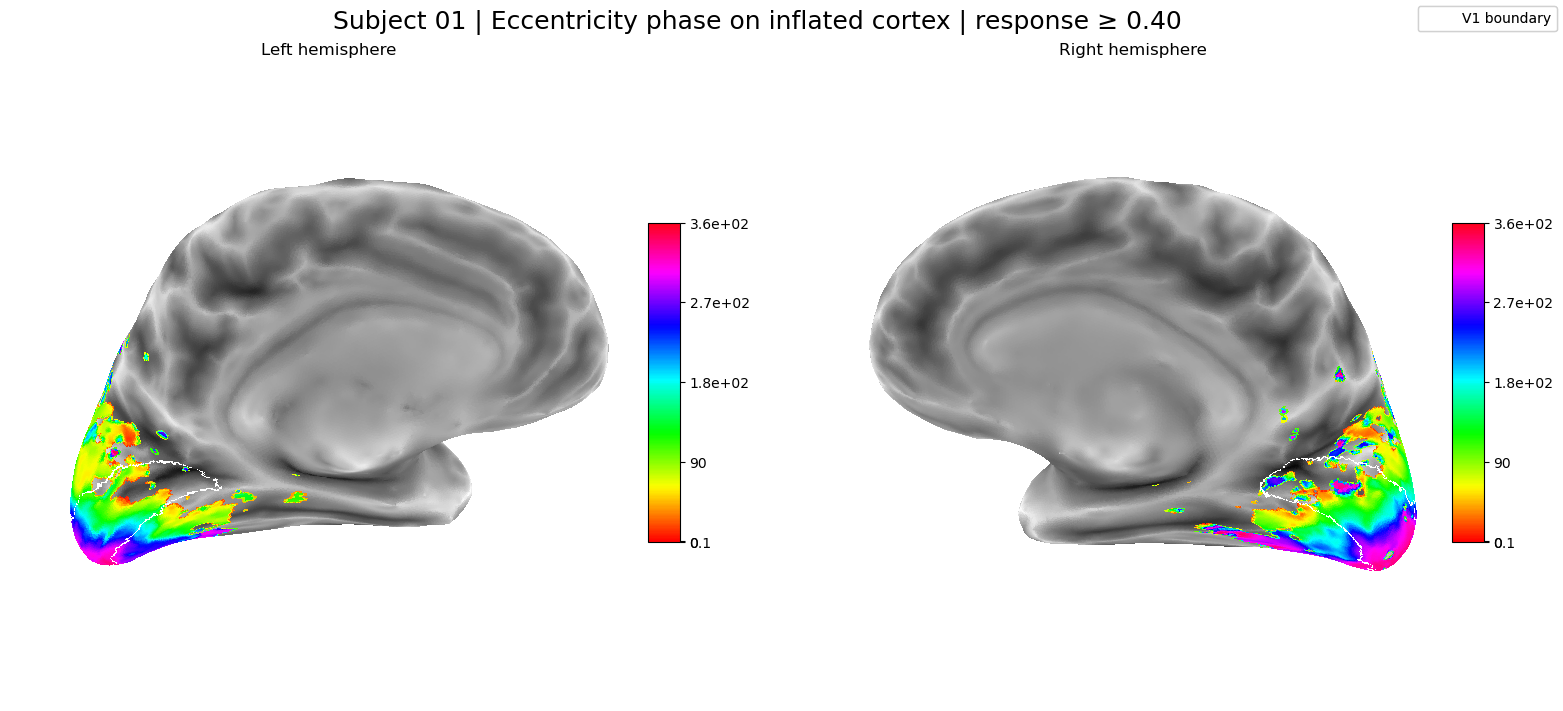

Saved: /home/jovyan/junruz/forrestgump/sub-01_retinotopy_eccentricity_V1-overlay.png


In [6]:
plot_retinotopy_with_v1("eccentricity", eccentricity_output)